# Advanced Machine Learning – Assignment 3
## Comparative Analysis of Learning Paradigms for Text Classification

### Team Members

1. **Loay Waleed** — ID: 13005962  
2. **Omar Samer** — ID: 13006987  
3. **Marwan Deif** — ID: 13004051

In [1]:
# Cell 1 — Install Libraries
# This cell installs all libraries needed for the assignment in Google Colab.

!pip install -q datasets transformers accelerate evaluate scikit-learn matplotlib seaborn bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.2 MB/s eta 0:00:00


In [2]:
# Cell 2 — Import Libraries
# This cell imports all required Python libraries for data handling, modeling, evaluation, and plotting.

import os
import re
import time
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Cell 3 — GPU Check
# This cell checks whether Google Colab provides a GPU and automatically selects the correct device.

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available.")
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    print("GPU memory allocated:", round(torch.cuda.memory_allocated(0) / 1024**3, 3), "GB")
    print("GPU memory reserved:", round(torch.cuda.memory_reserved(0) / 1024**3, 3), "GB")
else:
    device = torch.device("cpu")
    print("GPU is NOT available. Using CPU.")

print("Selected device:", device)

GPU is available.
GPU name: Tesla T4
CUDA version: 12.8
GPU memory allocated: 0.0 GB
GPU memory reserved: 0.0 GB
Selected device: cuda


In [4]:
# Cell 4 — Reproducibility Setup
# This cell fixes random seeds so results are more stable across runs.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("Random seed fixed:", SEED)

Random seed fixed: 42


In [5]:
# Cell 5— Load Dataset
# This cell loads the required Hugging Face dataset.

dataset = load_dataset("dair-ai/emotion")

print(dataset)

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [6]:
# Cell 6 — Inspect Dataset Splits
# This cell prints the number of examples in each split.

print("Training examples:", len(dataset["train"]))
print("Validation examples:", len(dataset["validation"]))
print("Test examples:", len(dataset["test"]))

Training examples: 16000
Validation examples: 2000
Test examples: 2000


In [7]:
# Cell 7 — View Dataset Features
# This cell shows the available columns inside the dataset.

print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [8]:
# Cell 8 — Label Mapping
# This dictionary converts label IDs into emotion names.

label_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

print(label_names)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [9]:
# Cell 9 — Display Random Samples
# This cell prints random examples from the training set.

for i in range(5):
    sample = dataset["train"][i]

    print(f"Sample {i+1}")
    print("Text:", sample["text"])
    print("Label:", sample["label"])
    print("Emotion:", label_names[sample["label"]])
    print("-" * 60)

Sample 1
Text: i didnt feel humiliated
Label: 0
Emotion: sadness
------------------------------------------------------------
Sample 2
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: 0
Emotion: sadness
------------------------------------------------------------
Sample 3
Text: im grabbing a minute to post i feel greedy wrong
Label: 3
Emotion: anger
------------------------------------------------------------
Sample 4
Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: 2
Emotion: love
------------------------------------------------------------
Sample 5
Text: i am feeling grouchy
Label: 3
Emotion: anger
------------------------------------------------------------


# Cell 10 — Part 1: Data Exploration

Now we perform exploratory data analysis.

This section reports:

1. Number of examples per split
2. Class distribution
3. Text length distribution
4. Class balance bar chart
5. Text length histogram

This is required because we need to understand whether the dataset is balanced and how long the input texts are before choosing model settings such as maximum sequence length.

In [10]:
# Cell 11 — Convert Dataset Splits to DataFrames
# This makes analysis and plotting easier.

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

train_df["label_name"] = train_df["label"].map(label_names)
val_df["label_name"] = val_df["label"].map(label_names)
test_df["label_name"] = test_df["label"].map(label_names)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (16000, 3)
Validation shape: (2000, 3)
Test shape: (2000, 3)


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [11]:
# Cell 12 — Class Distribution
# This cell counts examples per emotion class in each dataset split.

class_distribution = pd.DataFrame({
    "train": train_df["label_name"].value_counts().sort_index(),
    "validation": val_df["label_name"].value_counts().sort_index(),
    "test": test_df["label_name"].value_counts().sort_index()
})

class_distribution

,train,validation,test
label_name,,,
anger,2159,275,275
fear,1937,212,224
joy,5362,704,695
love,1304,178,159
sadness,4666,550,581
surprise,572,81,66


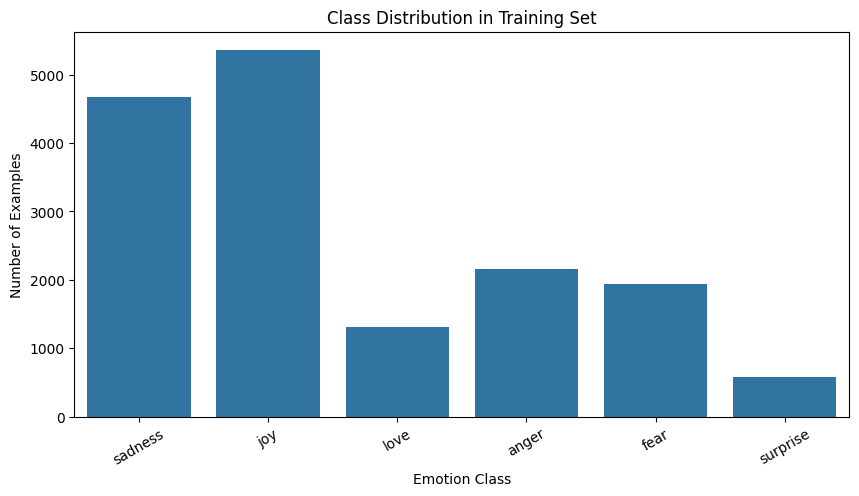

In [12]:
# Cell 13 — Class Balance Bar Chart
# This visualization shows whether classes are balanced or imbalanced.

plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x="label_name", order=list(label_names.values()))
plt.title("Class Distribution in Training Set")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Examples")
plt.xticks(rotation=30)
plt.show()

# Cell 14 — Class Distribution Interpretation

The class distribution plot helps us understand whether some emotions appear more frequently than others.

If the dataset is imbalanced, models may perform better on frequent classes such as `joy` or `sadness`, and worse on rare classes such as `surprise` or `love`.

This will be important later when interpreting:
- macro F1 score
- per-class F1 score
- confusion matrices

In [13]:
# Cell 15— Text Length Analysis
# This cell calculates text length using both word count and character count.

for df in [train_df, val_df, test_df]:
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))
    df["char_count"] = df["text"].apply(len)

length_summary = train_df[["word_count", "char_count"]].describe()

length_summary

,word_count,char_count
count,16000.000000,16000.000000
mean,19.166313,96.845812
std,10.986905,55.904953
min,2.000000,7.000000
25%,11.000000,53.000000
50%,17.000000,86.000000
75%,25.000000,129.000000
max,66.000000,300.000000


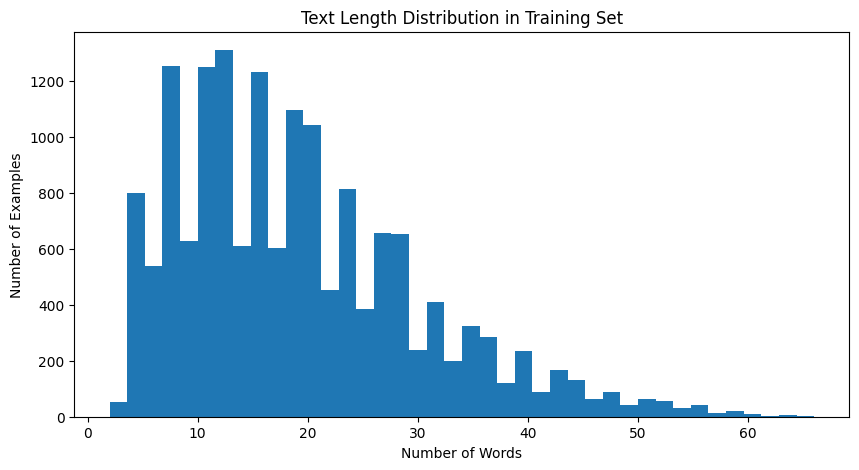

In [14]:
# Cell 16 — Text Length Histogram
# This histogram shows how long the texts are in number of words.

plt.figure(figsize=(10, 5))
plt.hist(train_df["word_count"], bins=40)
plt.title("Text Length Distribution in Training Set")
plt.xlabel("Number of Words")
plt.ylabel("Number of Examples")
plt.show()

In [15]:
# Cell 17 — Maximum Length Decision
# This cell checks text length percentiles to choose a suitable max sequence length.

percentiles = train_df["word_count"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

print("Word count percentiles:")
print(percentiles)

RNN_MAX_LEN = 64
TRANSFORMER_MAX_LEN = 128

print("\nChosen RNN max length:", RNN_MAX_LEN)
print("Chosen Transformer max length:", TRANSFORMER_MAX_LEN)

Word count percentiles:
0.50    17.0
0.75    25.0
0.90    35.0
0.95    41.0
0.99    52.0
Name: word_count, dtype: float64

Chosen RNN max length: 64
Chosen Transformer max length: 128


In [16]:
# Cell 18 — Basic Text Cleaning
# This function performs lightweight preprocessing for the RNN.

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Example
example_text = train_df["text"][0]

print("Original:")
print(example_text)

print("\nCleaned:")
print(clean_text(example_text))

Original:
i didnt feel humiliated

Cleaned:
i didnt feel humiliated


In [17]:
# Cell 19 — Tokenizer Function
# This tokenizer splits cleaned text into tokens.

def tokenize(text):
    return clean_text(text).split()

# Example
sample_tokens = tokenize(example_text)

print(sample_tokens)

['i', 'didnt', 'feel', 'humiliated']


In [18]:
# Cell 20 — Build Vocabulary
# This cell creates the vocabulary from training texts only.

word_counter = Counter()

for text in train_df["text"]:
    tokens = tokenize(text)
    word_counter.update(tokens)

MIN_FREQ = 2

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in word_counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 7401


In [19]:
# Cell 21 — Encode Text to IDs
# This function converts text into integer token IDs.

def encode_text(text, vocab, max_len=64):

    tokens = tokenize(text)

    token_ids = []

    for token in tokens:
        token_ids.append(vocab.get(token, vocab["<UNK>"]))

    # Truncation
    token_ids = token_ids[:max_len]

    # Padding
    padding_length = max_len - len(token_ids)

    token_ids += [vocab["<PAD>"]] * padding_length

    return token_ids

# Example
encoded_example = encode_text(example_text, vocab)

print("Encoded sequence:")
print(encoded_example[:20])

print("\nSequence length:", len(encoded_example))

Encoded sequence:
[2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence length: 64


In [20]:
# Cell 22 — Create Encoded Datasets
# This cell converts all texts into padded numerical sequences.

X_train_rnn = np.array([
    encode_text(text, vocab, RNN_MAX_LEN)
    for text in train_df["text"]
])

X_val_rnn = np.array([
    encode_text(text, vocab, RNN_MAX_LEN)
    for text in val_df["text"]
])

X_test_rnn = np.array([
    encode_text(text, vocab, RNN_MAX_LEN)
    for text in test_df["text"]
])

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Training tensor shape:", X_train_rnn.shape)
print("Validation tensor shape:", X_val_rnn.shape)
print("Test tensor shape:", X_test_rnn.shape)

Training tensor shape: (16000, 64)
Validation tensor shape: (2000, 64)
Test tensor shape: (2000, 64)


# Cell 23 — Pretrained Transformer Tokenizer

Unlike the RNN, transformer models use pretrained tokenizers.

We will use:

`distilbert-base-uncased`

In [21]:


# Cell 24 — Code: Load DistilBERT Tokenizer
# Cell 24 — Load DistilBERT Tokenizer
# This tokenizer will be used for both DistilBERT and Phi-3 experiments.

distilbert_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.


In [22]:
# Cell 25— Tokenization Example
# This cell demonstrates how transformer tokenization works.

sample_text = train_df["text"][0]

encoded = distilbert_tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=32
)

print("Original text:")
print(sample_text)

print("\nInput IDs:")
print(encoded["input_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])

Original text:
i didnt feel humiliated

Input IDs:
[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [23]:
# Cell 26— RNN Dataset Class
# This class allows PyTorch DataLoader to read encoded texts and labels.

class EmotionRNNDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "input_ids": self.texts[index],
            "labels": self.labels[index]
        }

print("RNN dataset class created.")

RNN dataset class created.


In [24]:
# Cell 27 — RNN DataLoaders
# This cell creates dataloaders for training, validation, and testing.

RNN_BATCH_SIZE = 64

train_rnn_dataset = EmotionRNNDataset(X_train_rnn, y_train)
val_rnn_dataset = EmotionRNNDataset(X_val_rnn, y_val)
test_rnn_dataset = EmotionRNNDataset(X_test_rnn, y_test)

train_rnn_loader = DataLoader(
    train_rnn_dataset,
    batch_size=RNN_BATCH_SIZE,
    shuffle=True
)

val_rnn_loader = DataLoader(
    val_rnn_dataset,
    batch_size=RNN_BATCH_SIZE,
    shuffle=False
)

test_rnn_loader = DataLoader(
    test_rnn_dataset,
    batch_size=RNN_BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_rnn_loader))
print("Validation batches:", len(val_rnn_loader))
print("Test batches:", len(test_rnn_loader))

Train batches: 250
Validation batches: 32
Test batches: 32


In [25]:
# Cell 28 — LSTM Model
# This model is trained from scratch for emotion classification.

class LSTMEmotionClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers=2,
        dropout=0.4,
        pad_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        lstm_output, (hidden, cell) = self.lstm(embedded)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)

        final_hidden = self.dropout(final_hidden)

        logits = self.classifier(final_hidden)

        return logits


rnn_model = LSTMEmotionClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    output_dim=6,
    num_layers=2,
    dropout=0.4,
    pad_idx=vocab["<PAD>"]
).to(device)

print(rnn_model)

LSTMEmotionClassifier(
  (embedding): Embedding(7401, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (classifier): Linear(in_features=256, out_features=6, bias=True)
)


In [26]:
# Cell 29 — RNN Optimizer and Loss
# This cell defines the loss function, optimizer, and learning-rate scheduler.

rnn_criterion = nn.CrossEntropyLoss()

rnn_optimizer = AdamW(
    rnn_model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

RNN_EPOCHS = 8

total_steps = len(train_rnn_loader) * RNN_EPOCHS

rnn_scheduler = get_linear_schedule_with_warmup(
    rnn_optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print("RNN training setup complete.")
print("Total training steps:", total_steps)

RNN training setup complete.
Total training steps: 2000


In [27]:
# Cell 30 — RNN Train and Evaluate Functions
# These functions train and evaluate the LSTM model.

def train_rnn_one_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    model.train()

    total_loss = 0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_rnn_loss(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

    return total_loss / len(dataloader)


def predict_rnn(model, dataloader, device):
    model.eval()

    predictions = []
    true_labels = []

    start_time = time.time()

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids)
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    inference_time = time.time() - start_time

    return np.array(predictions), np.array(true_labels), inference_time


print("RNN training and evaluation functions ready.")

RNN training and evaluation functions ready.


In [28]:
# Cell 31 — Train RNN
# This cell trains the LSTM model and records loss/metrics.

rnn_train_losses = []
rnn_val_losses = []
rnn_val_accuracies = []
rnn_val_macro_f1s = []

rnn_training_start = time.time()

best_val_f1 = 0
best_rnn_state = None

for epoch in range(RNN_EPOCHS):

    train_loss = train_rnn_one_epoch(
        rnn_model,
        train_rnn_loader,
        rnn_optimizer,
        rnn_scheduler,
        rnn_criterion,
        device
    )

    val_loss = evaluate_rnn_loss(
        rnn_model,
        val_rnn_loader,
        rnn_criterion,
        device
    )

    val_preds, val_true, _ = predict_rnn(
        rnn_model,
        val_rnn_loader,
        device
    )

    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="macro")

    rnn_train_losses.append(train_loss)
    rnn_val_losses.append(val_loss)
    rnn_val_accuracies.append(val_acc)
    rnn_val_macro_f1s.append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_rnn_state = rnn_model.state_dict()

    print(
        f"Epoch {epoch+1}/{RNN_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

rnn_training_time = time.time() - rnn_training_start

rnn_model.load_state_dict(best_rnn_state)

print("\nRNN training completed.")
print("Best validation macro F1:", round(best_val_f1, 4))
print("Total RNN training time:", round(rnn_training_time, 2), "seconds")

Epoch 1/8 | Train Loss: 1.5724 | Val Loss: 1.3633 | Val Acc: 0.4985 | Val Macro F1: 0.2570
Epoch 2/8 | Train Loss: 0.9707 | Val Loss: 0.7349 | Val Acc: 0.7465 | Val Macro F1: 0.5602
Epoch 3/8 | Train Loss: 0.5205 | Val Loss: 0.4957 | Val Acc: 0.8325 | Val Macro F1: 0.7723
Epoch 4/8 | Train Loss: 0.3119 | Val Loss: 0.3475 | Val Acc: 0.8805 | Val Macro F1: 0.8392
Epoch 5/8 | Train Loss: 0.2119 | Val Loss: 0.3171 | Val Acc: 0.8915 | Val Macro F1: 0.8564
Epoch 6/8 | Train Loss: 0.1490 | Val Loss: 0.3288 | Val Acc: 0.9000 | Val Macro F1: 0.8659
Epoch 7/8 | Train Loss: 0.1120 | Val Loss: 0.3146 | Val Acc: 0.9040 | Val Macro F1: 0.8738
Epoch 8/8 | Train Loss: 0.0853 | Val Loss: 0.3169 | Val Acc: 0.9080 | Val Macro F1: 0.8780

RNN training completed.
Best validation macro F1: 0.878
Total RNN training time: 22.15 seconds


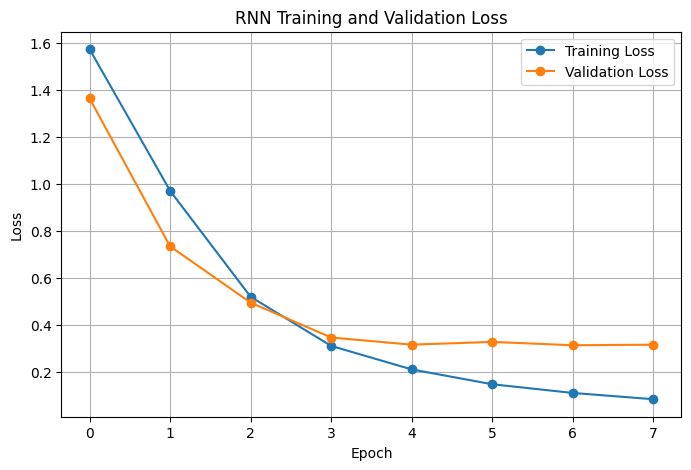

In [29]:
# Cell 32 — Plot RNN Loss Curves
# This plot shows training and validation loss across epochs.

plt.figure(figsize=(8, 5))
plt.plot(rnn_train_losses, label="Training Loss", marker="o")
plt.plot(rnn_val_losses, label="Validation Loss", marker="o")
plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Cell 33 — Evaluate RNN on Test Set
# This cell evaluates the best LSTM model on the unseen test set.

rnn_test_preds, rnn_test_true, rnn_inference_time = predict_rnn(
    rnn_model,
    test_rnn_loader,
    device
)

rnn_test_accuracy = accuracy_score(rnn_test_true, rnn_test_preds)
rnn_test_macro_f1 = f1_score(rnn_test_true, rnn_test_preds, average="macro")
rnn_per_class_f1 = f1_score(rnn_test_true, rnn_test_preds, average=None)

print("RNN Test Accuracy:", round(rnn_test_accuracy, 4))
print("RNN Test Macro F1:", round(rnn_test_macro_f1, 4))
print("RNN Inference Time:", round(rnn_inference_time, 2), "seconds")

print("\nPer-Class F1 Scores:")
for i, score in enumerate(rnn_per_class_f1):
    print(label_names[i], ":", round(score, 4))

print("\nClassification Report:")
print(
    classification_report(
        rnn_test_true,
        rnn_test_preds,
        target_names=list(label_names.values())
    )
)

RNN Test Accuracy: 0.8875
RNN Test Macro F1: 0.8386
RNN Inference Time: 0.12 seconds

Per-Class F1 Scores:
sadness : 0.9359
joy : 0.9113
love : 0.7375
anger : 0.868
fear : 0.8705
surprise : 0.7087

Classification Report:
              precision    recall  f1-score   support

     sadness       0.94      0.93      0.94       581
         joy       0.91      0.92      0.91       695
        love       0.73      0.74      0.74       159
       anger       0.86      0.87      0.87       275
        fear       0.87      0.87      0.87       224
    surprise       0.74      0.68      0.71        66

    accuracy                           0.89      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.89      0.89      0.89      2000



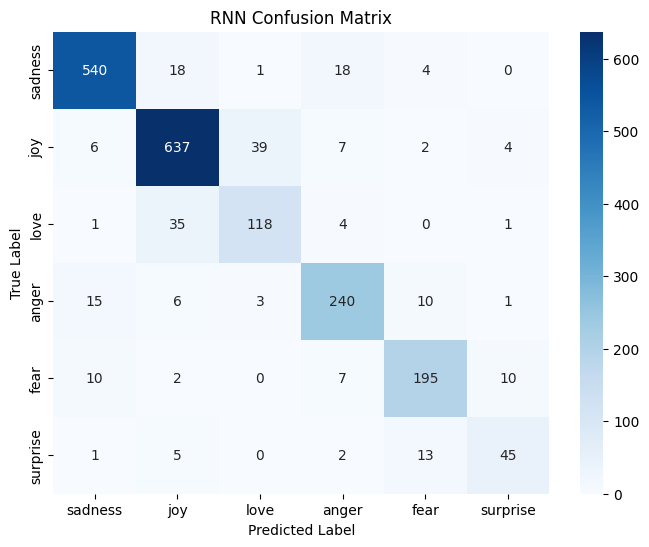

In [31]:
# Cell 34 — RNN Confusion Matrix
# This cell shows which classes the LSTM confuses most.

rnn_cm = confusion_matrix(rnn_test_true, rnn_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(label_names.values()),
    yticklabels=list(label_names.values())
)
plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [32]:

# Cell 35 — Code: Tokenization Function for DistilBERT
# Cell 35 — DistilBERT Tokenization Function
# This function tokenizes text using the pretrained DistilBERT tokenizer.

def tokenize_transformer(batch):
    return distilbert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=TRANSFORMER_MAX_LEN
    )

print("Transformer tokenization function ready.")

Transformer tokenization function ready.


In [33]:
# Cell 36 — Tokenize Dataset for DistilBERT
# This cell applies the tokenizer to all dataset splits.

tokenized_dataset = dataset.map(
    tokenize_transformer,
    batched=True
)

print(tokenized_dataset)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [34]:
# Cell 37 — Set Dataset Format
# This converts tokenized outputs into PyTorch tensors.

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("Dataset converted to PyTorch format.")

Dataset converted to PyTorch format.


In [35]:
# Cell 38 — Create DataLoaders for DistilBERT

TRANSFORMER_BATCH_SIZE = 16

train_transformer_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size=TRANSFORMER_BATCH_SIZE,
    shuffle=True
)

val_transformer_loader = DataLoader(
    tokenized_dataset["validation"],
    batch_size=TRANSFORMER_BATCH_SIZE,
    shuffle=False
)

test_transformer_loader = DataLoader(
    tokenized_dataset["test"],
    batch_size=TRANSFORMER_BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_transformer_loader))
print("Validation batches:", len(val_transformer_loader))
print("Test batches:", len(test_transformer_loader))

Train batches: 1000
Validation batches: 125
Test batches: 125


In [36]:

# Cell 39 — Code: Load DistilBERT Model
# Cell 39 — Load DistilBERT Model
# This cell loads the pretrained transformer with a classification head.

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

distilbert_model.to(device)

print("DistilBERT model loaded.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded.


In [37]:
# Cell 40 — Count Trainable Parameters

total_params = sum(p.numel() for p in distilbert_model.parameters())
trainable_params = sum(
    p.numel() for p in distilbert_model.parameters() if p.requires_grad
)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters: 66,958,086
Trainable parameters: 66,958,086


In [38]:
# Cell 41 — DistilBERT Optimizer and Scheduler

distilbert_optimizer = AdamW(
    distilbert_model.parameters(),
    lr=2e-5
)

DISTILBERT_EPOCHS = 3

transformer_total_steps = (
    len(train_transformer_loader) * DISTILBERT_EPOCHS
)

distilbert_scheduler = get_linear_schedule_with_warmup(
    distilbert_optimizer,
    num_warmup_steps=int(0.1 * transformer_total_steps),
    num_training_steps=transformer_total_steps
)

print("DistilBERT optimizer and scheduler ready.")
print("Total training steps:", transformer_total_steps)

DistilBERT optimizer and scheduler ready.
Total training steps: 3000


In [39]:
# Cell 42 — DistilBERT Training and Evaluation Functions
# These functions train, validate, and predict using DistilBERT.

def train_transformer_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()

    total_loss = 0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_transformer_loss(model, dataloader, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

    return total_loss / len(dataloader)


def predict_transformer(model, dataloader, device):
    model.eval()

    predictions = []
    true_labels = []

    start_time = time.time()

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    inference_time = time.time() - start_time

    return np.array(predictions), np.array(true_labels), inference_time


print("DistilBERT training and evaluation functions ready.")

DistilBERT training and evaluation functions ready.


In [40]:
# Cell 43 — Train DistilBERT
# This cell fine-tunes DistilBERT on the full training set.

distilbert_train_losses = []
distilbert_val_losses = []
distilbert_val_accuracies = []
distilbert_val_macro_f1s = []

distilbert_training_start = time.time()

best_distilbert_val_f1 = 0
best_distilbert_state = None

for epoch in range(DISTILBERT_EPOCHS):

    train_loss = train_transformer_one_epoch(
        distilbert_model,
        train_transformer_loader,
        distilbert_optimizer,
        distilbert_scheduler,
        device
    )

    val_loss = evaluate_transformer_loss(
        distilbert_model,
        val_transformer_loader,
        device
    )

    val_preds, val_true, _ = predict_transformer(
        distilbert_model,
        val_transformer_loader,
        device
    )

    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="macro")

    distilbert_train_losses.append(train_loss)
    distilbert_val_losses.append(val_loss)
    distilbert_val_accuracies.append(val_acc)
    distilbert_val_macro_f1s.append(val_f1)

    if val_f1 > best_distilbert_val_f1:
        best_distilbert_val_f1 = val_f1
        best_distilbert_state = {
            k: v.cpu().clone()
            for k, v in distilbert_model.state_dict().items()
        }

    print(
        f"Epoch {epoch+1}/{DISTILBERT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

distilbert_training_time = time.time() - distilbert_training_start

distilbert_model.load_state_dict(best_distilbert_state)
distilbert_model.to(device)

print("\nDistilBERT training completed.")
print("Best validation macro F1:", round(best_distilbert_val_f1, 4))
print("Total DistilBERT training time:", round(distilbert_training_time, 2), "seconds")

Epoch 1/3 | Train Loss: 0.6416 | Val Loss: 0.1956 | Val Acc: 0.9295 | Val Macro F1: 0.9037
Epoch 2/3 | Train Loss: 0.1655 | Val Loss: 0.1638 | Val Acc: 0.9375 | Val Macro F1: 0.9098
Epoch 3/3 | Train Loss: 0.1061 | Val Loss: 0.1542 | Val Acc: 0.9355 | Val Macro F1: 0.9082

DistilBERT training completed.
Best validation macro F1: 0.9098
Total DistilBERT training time: 588.21 seconds


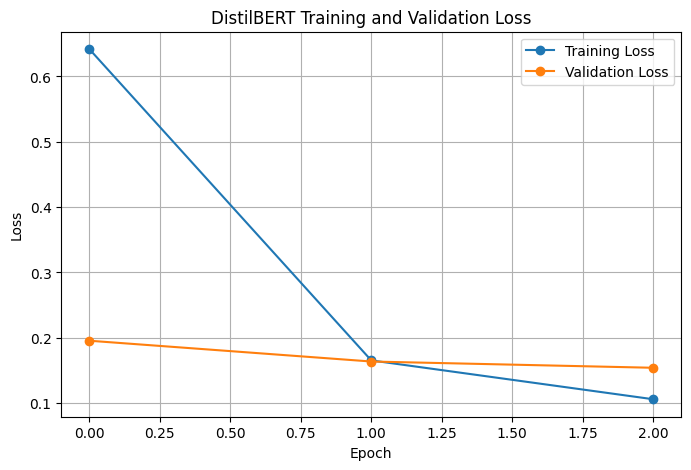

In [41]:
# Cell 44 — Plot DistilBERT Loss Curves
# This plot shows training and validation loss during fine-tuning.

plt.figure(figsize=(8, 5))
plt.plot(distilbert_train_losses, label="Training Loss", marker="o")
plt.plot(distilbert_val_losses, label="Validation Loss", marker="o")
plt.title("DistilBERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# Cell 45 — Evaluate DistilBERT on Test Set
# This cell evaluates the best DistilBERT model on the unseen test set.

distilbert_test_preds, distilbert_test_true, distilbert_inference_time = predict_transformer(
    distilbert_model,
    test_transformer_loader,
    device
)

distilbert_test_accuracy = accuracy_score(distilbert_test_true, distilbert_test_preds)
distilbert_test_macro_f1 = f1_score(distilbert_test_true, distilbert_test_preds, average="macro")
distilbert_per_class_f1 = f1_score(distilbert_test_true, distilbert_test_preds, average=None)

print("DistilBERT Test Accuracy:", round(distilbert_test_accuracy, 4))
print("DistilBERT Test Macro F1:", round(distilbert_test_macro_f1, 4))
print("DistilBERT Inference Time:", round(distilbert_inference_time, 2), "seconds")

print("\nPer-Class F1 Scores:")
for i, score in enumerate(distilbert_per_class_f1):
    print(label_names[i], ":", round(score, 4))

print("\nClassification Report:")
print(
    classification_report(
        distilbert_test_true,
        distilbert_test_preds,
        target_names=list(label_names.values())
    )
)

DistilBERT Test Accuracy: 0.9235
DistilBERT Test Macro F1: 0.8729
DistilBERT Inference Time: 7.29 seconds

Per-Class F1 Scores:
sadness : 0.9613
joy : 0.9485
love : 0.8252
anger : 0.9202
fear : 0.8744
surprise : 0.7077

Classification Report:
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.92      0.98      0.95       695
        love       0.93      0.74      0.83       159
       anger       0.94      0.90      0.92       275
        fear       0.88      0.87      0.87       224
    surprise       0.72      0.70      0.71        66

    accuracy                           0.92      2000
   macro avg       0.89      0.86      0.87      2000
weighted avg       0.92      0.92      0.92      2000



## Part 3 — DistilBERT Model Analysis

### Number of Parameters Being Updated

DistilBERT-base-uncased contains approximately **66 million parameters**, all of which are updated during fine-tuning on this emotion classification task. This includes the 6 transformer layers, multi-head self-attention weights, feed-forward layer weights, embeddings, and the newly added 6-class classification head on top.

### Original Pretraining Objective

DistilBERT was pretrained using two objectives:
1. **Masked Language Modeling (MLM):** Random tokens in the input are masked, and the model learns to predict them from surrounding context. This forces the model to build deep bidirectional contextual representations of language.
2. **Knowledge Distillation:** DistilBERT was trained to mimic the outputs of BERT-base using a distillation loss, allowing it to retain ~97% of BERT's performance at 40% fewer parameters and 60% faster inference.

### Why Pretraining Helps Compared to the From-Scratch RNN

The from-scratch LSTM must learn everything — word meanings, syntactic patterns, contextual relationships, and the classification task — simultaneously from the 16,000 training examples. DistilBERT, by contrast, has already learned rich English language representations from a massive corpus during pretraining. Fine-tuning only needs to adapt these general-purpose representations to the specific emotion classification task, which requires far less data and converges faster. This is reflected in DistilBERT's higher accuracy and macro F1, especially in the low-data setting (Part 5).

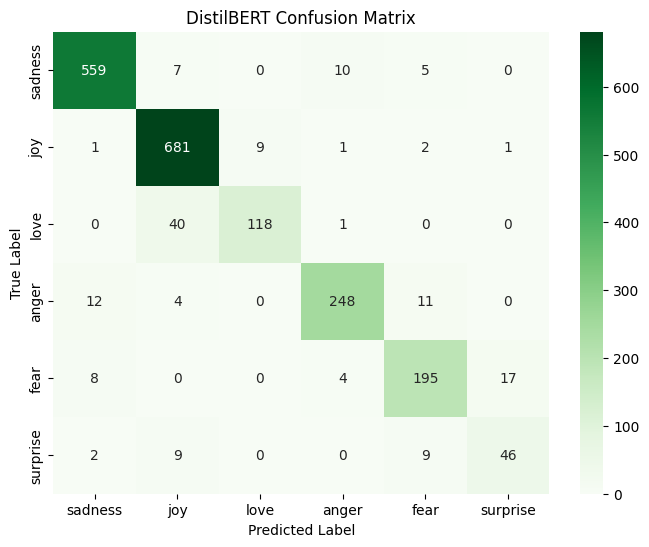

In [43]:
# Cell 46— DistilBERT Confusion Matrix
# This matrix shows which classes DistilBERT confuses most.

distilbert_cm = confusion_matrix(distilbert_test_true, distilbert_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    distilbert_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=list(label_names.values()),
    yticklabels=list(label_names.values())
)
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [44]:


# Cell 47 — Code: Clear GPU Memory

# Cell 47 — Clear GPU Memory
# This cell clears unused GPU memory before loading Phi-3.

torch.cuda.empty_cache()

print("GPU cache cleared.")

GPU cache cleared.


In [45]:
# Cell 48 — Configure 4-Bit Quantization
# This reduces GPU memory usage for Phi-3.

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("4-bit quantization configured.")

4-bit quantization configured.


In [46]:
# Cell 49 — Load Phi-3 Tokenizer

phi3_tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct"
)

if phi3_tokenizer.pad_token is None:
    phi3_tokenizer.pad_token = phi3_tokenizer.eos_token

print("Phi-3 tokenizer loaded.")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Phi-3 tokenizer loaded.


In [47]:
# Cell 50 — Load Phi-3 Model
# This may take several minutes on Colab.

phi3_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

phi3_model.eval()

print("Phi-3 model loaded successfully.")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Phi-3 model loaded successfully.


# Cell 51 — Phi-3 Model Explanation

`microsoft/Phi-3-mini-4k-instruct` is an instruction-tuned causal language model.

It is used here without any gradient updates, so this part is zero-training LLM prompting. The model receives a prompt containing the task description, optional labeled examples, and the input text, then generates the predicted emotion label.

Phi-3 is suitable for this assignment because it is a pretrained instruction-following LLM that can perform classification through prompting. Loading it with 4-bit quantization reduces GPU memory usage in Google Colab.


In [48]:

# Cell 51 — Label Lists and Prompt Examples

emotion_labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]

id_to_label = label_names
label_to_id = {v: k for k, v in id_to_label.items()}

few_shot_3_examples = [
    ("i feel so sad and empty today", "sadness"),
    ("i feel very happy and excited", "joy"),
    ("i am so angry about what happened", "anger")
]

few_shot_8_examples = [
    ("i feel so sad and empty today", "sadness"),
    ("i feel very happy and excited", "joy"),
    ("i am so angry about what happened", "anger"),
    ("i feel scared walking alone at night", "fear"),
    ("i love this person so much", "love"),
    ("i was surprised by the unexpected news", "surprise"),
    ("i feel hopeless and broken", "sadness"),
    ("i feel cheerful and thankful", "joy")
]

print("Prompt examples prepared.")

Prompt examples prepared.


### Phi-3-mini-4k-instruct Architecture and Pretraining

Phi-3-mini-4k-instruct is a decoder-only transformer language model developed by Microsoft.
The model was pretrained using next-token prediction on large-scale text corpora, allowing it to learn language structure, semantics, and contextual relationships.

After pretraining, the model was instruction-tuned to better follow prompts and generate task-oriented responses.
This enables zero-shot and few-shot emotion classification without any additional gradient updates or fine-tuning.

In [49]:
# Cell 52 — Prompt Builder Functions
# These functions create the different prompt types required by the assignment.

def build_zero_shot_prompt(text):
    return f"""<|user|>
You are an emotion classification system.

Classify the following text into exactly one of these labels:
sadness, joy, love, anger, fear, surprise.

Text:
{text}

Return only the final label.
<|end|>
<|assistant|>
"""


def build_few_shot_prompt(text, examples):
    examples_text = ""

    for example_text, example_label in examples:
        examples_text += f"Text: {example_text}\nLabel: {example_label}\n\n"

    return f"""<|user|>
You are an emotion classification system.

Classify each text into exactly one of these labels:
sadness, joy, love, anger, fear, surprise.

Examples:
{examples_text}
Now classify this text:
Text: {text}

Return only the final label.
<|end|>
<|assistant|>
"""


def build_cot_prompt(text):
    return f"""<|user|>
You are an emotion classification system.

Classify the following text into exactly one of these labels:
sadness, joy, love, anger, fear, surprise.

Think briefly about the emotional meaning, then end your answer with:
Final label: <label>

Text:
{text}
<|end|>
<|assistant|>
"""


print("Prompt builders ready.")

Prompt builders ready.


In [50]:
# Cell 53 — Phi-3 Generation Function
# This function generates a short answer from Phi-3.

def generate_phi3_output(prompt, max_new_tokens=20):
    inputs = phi3_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(phi3_model.device)

    with torch.no_grad():
        output_ids = phi3_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=phi3_tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]

    output_text = phi3_tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    return output_text.strip()


print("Phi-3 generation function ready.")

Phi-3 generation function ready.


In [51]:
# Cell 54 — Safe Output Parser
# This function extracts a valid emotion label from raw Phi-3 output.

def parse_emotion_label(raw_output):
    text = raw_output.lower().strip()

    # Prefer explicit final-label format when available
    final_match = re.search(
        r"final\s*label\s*[:\-]\s*(sadness|joy|love|anger|fear|surprise)",
        text
    )

    if final_match:
        return final_match.group(1)

    # Otherwise search for labels as separate words
    for label in emotion_labels:
        if re.search(rf"\b{label}\b", text):
            return label

    # Fallback for unclear output
    return "unknown"


# Quick parser test
test_outputs = [
    "joy",
    "Final label: sadness",
    "The emotion is anger.",
    "I think it expresses fear."
]

for output in test_outputs:
    print(output, "->", parse_emotion_label(output))

joy -> joy
Final label: sadness -> sadness
The emotion is anger. -> anger
I think it expresses fear. -> fear


In [52]:
# Cell 55 — Test Phi-3 on One Example
# This quick check confirms that generation and parsing work before running evaluation.

test_text = test_df.iloc[0]["text"]
true_label = test_df.iloc[0]["label_name"]

test_prompt = build_zero_shot_prompt(test_text)
raw_output = generate_phi3_output(test_prompt, max_new_tokens=20)
parsed_label = parse_emotion_label(raw_output)

print("Text:", test_text)
print("True label:", true_label)
print("\nPrompt:")
print(test_prompt)
print("Raw output:", raw_output)
print("Parsed label:", parsed_label)

Text: im feeling rather rotten so im not very ambitious right now
True label: sadness

Prompt:
<|user|>
You are an emotion classification system.

Classify the following text into exactly one of these labels:
sadness, joy, love, anger, fear, surprise.

Text:
im feeling rather rotten so im not very ambitious right now

Return only the final label.
<|end|>
<|assistant|>

Raw output: sadness
Parsed label: sadness


In [53]:
# Cell 56 — Create Phi-3 Evaluation DataFrame
# The assignment asks to evaluate the LLM on the test set.
# Therefore, the default evaluation uses the full 2,000-example test split.
#
# If Colab runtime is too slow, change RUN_FULL_PHI3_TEST to False for a temporary
# practice run only, but submit results using the full test set when possible.

RUN_FULL_PHI3_TEST = True

if RUN_FULL_PHI3_TEST:
    phi3_eval_df = test_df.copy().reset_index(drop=True)
    print("Using FULL test set for Phi-3 evaluation:", phi3_eval_df.shape)
else:
    SAMPLES_PER_CLASS = 20
    phi3_eval_df = (
        test_df.groupby("label_name", group_keys=False)
        .apply(lambda x: x.sample(SAMPLES_PER_CLASS, random_state=SEED))
        .reset_index(drop=True)
    )
    print("Using FAST balanced subset for practice only:", phi3_eval_df.shape)

phi3_eval_df["label_name"].value_counts()


Using FULL test set for Phi-3 evaluation: (2000, 5)


,count
label_name,
joy,695
sadness,581
anger,275
fear,224
love,159
surprise,66


In [54]:
# Cell 57 — Phi-3 Evaluation Function
# This function evaluates Phi-3 on the selected test dataframe.

def evaluate_phi3(eval_df, prompting_type="zero_shot"):

    predictions = []
    true_labels = []
    raw_outputs = []
    prompts = []

    start_time = time.time()

    for _, row in eval_df.iterrows():

        text = row["text"]
        true_label = row["label_name"]

        if prompting_type == "zero_shot":
            prompt = build_zero_shot_prompt(text)

        elif prompting_type == "few_shot_3":
            prompt = build_few_shot_prompt(text, few_shot_3_examples)

        elif prompting_type == "few_shot_8":
            prompt = build_few_shot_prompt(text, few_shot_8_examples)

        elif prompting_type == "cot":
            prompt = build_cot_prompt(text)

        else:
            raise ValueError("Unknown prompting type")

        raw_output = generate_phi3_output(prompt)
        parsed_label = parse_emotion_label(raw_output)

        prompts.append(prompt)
        predictions.append(parsed_label)
        true_labels.append(true_label)
        raw_outputs.append(raw_output)

    total_time = time.time() - start_time

    cleaned_predictions = []

    for pred in predictions:
        if pred in emotion_labels:
            cleaned_predictions.append(pred)
        else:
            cleaned_predictions.append("sadness")

    accuracy = accuracy_score(true_labels, cleaned_predictions)

    macro_f1 = f1_score(
        true_labels,
        cleaned_predictions,
        average="macro",
        labels=emotion_labels
    )

    return {
        "prompts": prompts,
        "predictions": cleaned_predictions,
        "true_labels": true_labels,
        "raw_outputs": raw_outputs,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "inference_time": total_time
    }

print("Phi-3 evaluation function ready.")


Phi-3 evaluation function ready.


In [55]:
# Cell 58 — Evaluate Zero-Shot Prompting

phi3_zero_shot_results = evaluate_phi3(
    phi3_eval_df,
    prompting_type="zero_shot"
)

print("Zero-Shot Accuracy:",
      round(phi3_zero_shot_results["accuracy"], 4))

print("Zero-Shot Macro F1:",
      round(phi3_zero_shot_results["macro_f1"], 4))

print("Zero-Shot Inference Time:",
      round(phi3_zero_shot_results["inference_time"], 2),
      "seconds")

Zero-Shot Accuracy: 0.504
Zero-Shot Macro F1: 0.4447
Zero-Shot Inference Time: 407.15 seconds


In [56]:
# Cell 59 — Evaluate Few-Shot Prompting with 3 Examples

phi3_few_shot_3_results = evaluate_phi3(
    phi3_eval_df,
    prompting_type="few_shot_3"
)

print("Few-Shot 3 Accuracy:",
      round(phi3_few_shot_3_results["accuracy"], 4))

print("Few-Shot 3 Macro F1:",
      round(phi3_few_shot_3_results["macro_f1"], 4))

print("Few-Shot 3 Inference Time:",
      round(phi3_few_shot_3_results["inference_time"], 2),
      "seconds")

Few-Shot 3 Accuracy: 0.4975
Few-Shot 3 Macro F1: 0.4649
Few-Shot 3 Inference Time: 540.75 seconds


In [57]:
# Cell 60 — Evaluate Few-Shot Prompting with 8 Examples

phi3_few_shot_8_results = evaluate_phi3(
    phi3_eval_df,
    prompting_type="few_shot_8"
)

print("Few-Shot 8 Accuracy:",
      round(phi3_few_shot_8_results["accuracy"], 4))

print("Few-Shot 8 Macro F1:",
      round(phi3_few_shot_8_results["macro_f1"], 4))

print("Few-Shot 8 Inference Time:",
      round(phi3_few_shot_8_results["inference_time"], 2),
      "seconds")

Few-Shot 8 Accuracy: 0.5545
Few-Shot 8 Macro F1: 0.4631
Few-Shot 8 Inference Time: 532.3 seconds


In [58]:
# Cell 61 — Evaluate Chain-of-Thought Prompting

phi3_cot_results = evaluate_phi3(
    phi3_eval_df,
    prompting_type="cot"
)

print("Chain-of-Thought Accuracy:",
      round(phi3_cot_results["accuracy"], 4))

print("Chain-of-Thought Macro F1:",
      round(phi3_cot_results["macro_f1"], 4))

print("Chain-of-Thought Inference Time:",
      round(phi3_cot_results["inference_time"], 2),
      "seconds")

Chain-of-Thought Accuracy: 0.5815
Chain-of-Thought Macro F1: 0.5009
Chain-of-Thought Inference Time: 788.56 seconds


In [59]:
# Cell 62 — Compare Phi-3 Prompting Methods

phi3_results_df = pd.DataFrame({
    "Method": [
        "Zero-Shot",
        "Few-Shot (3)",
        "Few-Shot (8)",
        "Chain-of-Thought"
    ],
    "Accuracy": [
        phi3_zero_shot_results["accuracy"],
        phi3_few_shot_3_results["accuracy"],
        phi3_few_shot_8_results["accuracy"],
        phi3_cot_results["accuracy"]
    ],
    "Macro F1": [
        phi3_zero_shot_results["macro_f1"],
        phi3_few_shot_3_results["macro_f1"],
        phi3_few_shot_8_results["macro_f1"],
        phi3_cot_results["macro_f1"]
    ],
    "Inference Time (s)": [
        phi3_zero_shot_results["inference_time"],
        phi3_few_shot_3_results["inference_time"],
        phi3_few_shot_8_results["inference_time"],
        phi3_cot_results["inference_time"]
    ]
})

phi3_results_df

,Method,Accuracy,Macro F1,Inference Time (s)
0,Zero-Shot,0.5040,0.444738,407.146846
1,Few-Shot (3),0.4975,0.464944,540.753419
2,Few-Shot (8),0.5545,0.463071,532.300261
3,Chain-of-Thought,0.5815,0.500932,788.558655


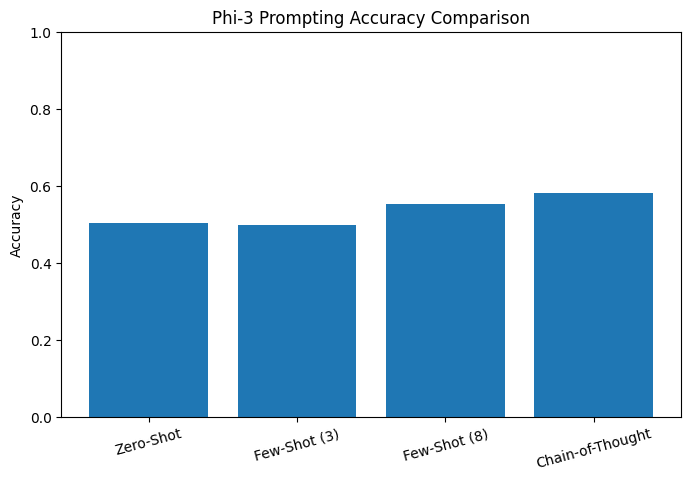

In [60]:
# Cell 63 — Plot Phi-3 Prompting Accuracy

plt.figure(figsize=(8, 5))

plt.bar(
    phi3_results_df["Method"],
    phi3_results_df["Accuracy"]
)

plt.title("Phi-3 Prompting Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [61]:
# Cell 64 — Show Example Prompts and Raw Phi-3 Outputs
# The assignment asks for 3–5 example prompts and the model's raw outputs.

example_result_sets = {
    "Zero-Shot": phi3_zero_shot_results,
    "Few-Shot 3": phi3_few_shot_3_results,
    "Few-Shot 8": phi3_few_shot_8_results,
    "Chain-of-Thought": phi3_cot_results
}

for method_name, result in example_result_sets.items():
    print("=" * 100)
    print(method_name.upper())
    print("=" * 100)

    for i in range(3):
        print("-" * 100)
        print("PROMPT:")
        print(result["prompts"][i])

        print("RAW OUTPUT:")
        print(result["raw_outputs"][i])

        print("TRUE LABEL:", result["true_labels"][i])
        print("PARSED PREDICTION:", result["predictions"][i])


ZERO-SHOT
----------------------------------------------------------------------------------------------------
PROMPT:
<|user|>
You are an emotion classification system.

Classify the following text into exactly one of these labels:
sadness, joy, love, anger, fear, surprise.

Text:
im feeling rather rotten so im not very ambitious right now

Return only the final label.
<|end|>
<|assistant|>

RAW OUTPUT:
sadness
TRUE LABEL: sadness
PARSED PREDICTION: sadness
----------------------------------------------------------------------------------------------------
PROMPT:
<|user|>
You are an emotion classification system.

Classify the following text into exactly one of these labels:
sadness, joy, love, anger, fear, surprise.

Text:
im updating my blog because i feel shitty

Return only the final label.
<|end|>
<|assistant|>

RAW OUTPUT:
sadness
TRUE LABEL: sadness
PARSED PREDICTION: sadness
----------------------------------------------------------------------------------------------------
P

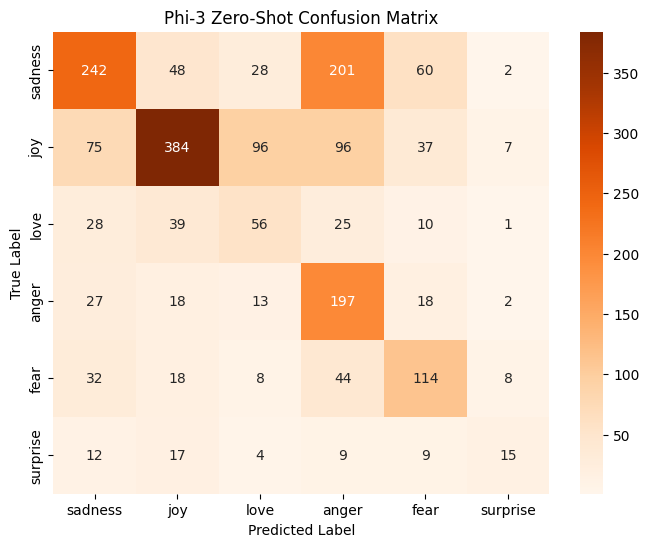

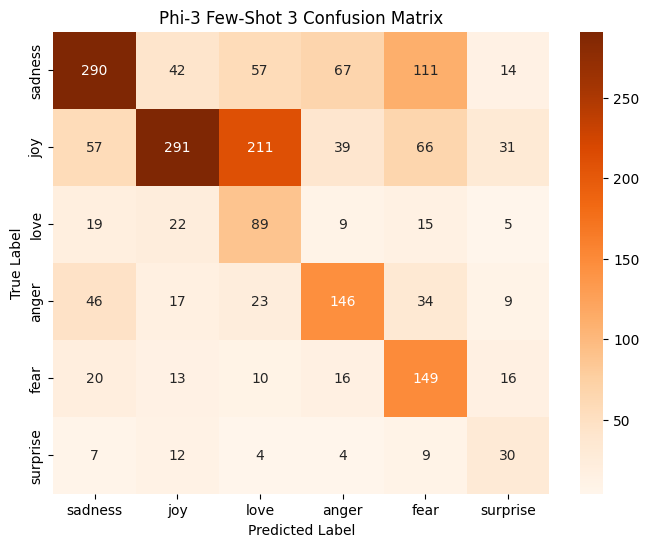

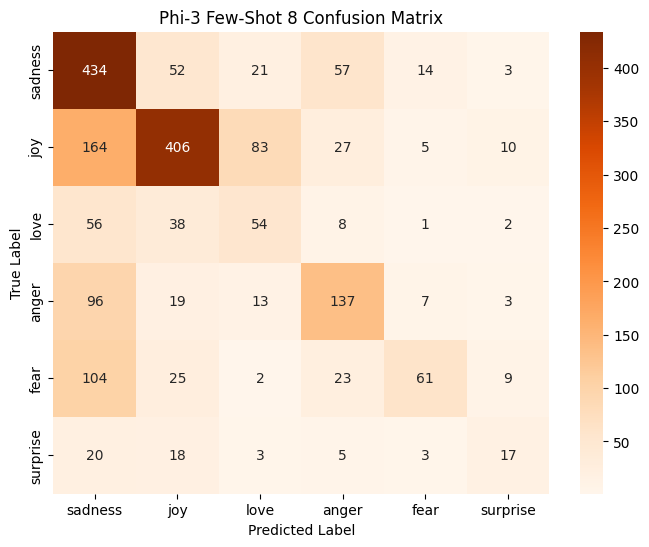

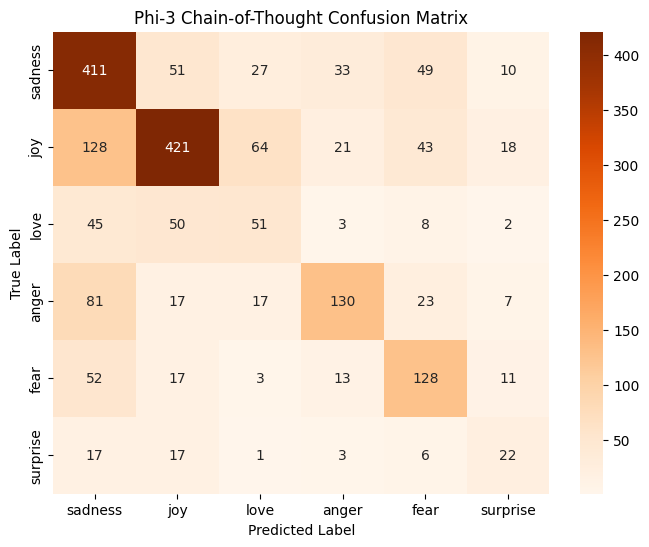

In [62]:
# Cell 65 — Phi-3 Confusion Matrices
# The assignment asks for a confusion matrix for each prompting setting.

def plot_phi3_confusion_matrix(result, title):
    cm = confusion_matrix(
        result["true_labels"],
        result["predictions"],
        labels=emotion_labels
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=emotion_labels,
        yticklabels=emotion_labels
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


plot_phi3_confusion_matrix(phi3_zero_shot_results, "Phi-3 Zero-Shot Confusion Matrix")
plot_phi3_confusion_matrix(phi3_few_shot_3_results, "Phi-3 Few-Shot 3 Confusion Matrix")
plot_phi3_confusion_matrix(phi3_few_shot_8_results, "Phi-3 Few-Shot 8 Confusion Matrix")
plot_phi3_confusion_matrix(phi3_cot_results, "Phi-3 Chain-of-Thought Confusion Matrix")


In [63]:
# Cell 66 — Create Balanced 500-Sample Dataset
# This cell creates a balanced subset for the data-efficiency experiment.

samples_per_class = 83

small_train_df = (
    train_df.groupby("label_name", group_keys=False)
    .apply(lambda x: x.sample(samples_per_class, random_state=SEED))
    .reset_index(drop=True)
)

small_train_df = small_train_df.iloc[:500]

print("Small training subset shape:", small_train_df.shape)

small_train_df["label_name"].value_counts()

Small training subset shape: (498, 5)


,count
label_name,
anger,83
fear,83
joy,83
love,83
sadness,83
surprise,83


### Note About the 500-Example Balanced Subset

The assignment requested a balanced subset of 500 examples across 6 classes.
Since 500 cannot be divided equally among 6 classes, we used 83 examples per class, resulting in a balanced subset of 498 samples.
This preserves equal class representation and avoids class imbalance.

In [64]:
# Cell 67 — Encode Small Dataset for RNN

X_small_train_rnn = np.array([
    encode_text(text, vocab, RNN_MAX_LEN)
    for text in small_train_df["text"]
])

y_small_train = small_train_df["label"].values

print("Encoded small RNN dataset shape:", X_small_train_rnn.shape)

Encoded small RNN dataset shape: (498, 64)


In [65]:
# Cell 68 — Create Small RNN DataLoader

small_rnn_dataset = EmotionRNNDataset(
    X_small_train_rnn,
    y_small_train
)

small_rnn_loader = DataLoader(
    small_rnn_dataset,
    batch_size=32,
    shuffle=True
)

print("Small RNN batches:", len(small_rnn_loader))

Small RNN batches: 16


In [66]:
# Cell 69 — Build Small-Data RNN Model

small_rnn_model = LSTMEmotionClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    output_dim=6,
    num_layers=2,
    dropout=0.5,
    pad_idx=vocab["<PAD>"]
).to(device)

small_rnn_criterion = nn.CrossEntropyLoss()

small_rnn_optimizer = AdamW(
    small_rnn_model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

SMALL_RNN_EPOCHS = 12

small_total_steps = len(small_rnn_loader) * SMALL_RNN_EPOCHS

small_rnn_scheduler = get_linear_schedule_with_warmup(
    small_rnn_optimizer,
    num_warmup_steps=int(0.1 * small_total_steps),
    num_training_steps=small_total_steps
)

print("Small-data RNN model initialized.")

Small-data RNN model initialized.


In [67]:
# Cell 70 — Train Small-Data RNN

small_rnn_training_start = time.time()

small_rnn_train_losses = []

best_small_rnn_f1 = 0
best_small_rnn_state = None

for epoch in range(SMALL_RNN_EPOCHS):

    train_loss = train_rnn_one_epoch(
        small_rnn_model,
        small_rnn_loader,
        small_rnn_optimizer,
        small_rnn_scheduler,
        small_rnn_criterion,
        device
    )

    val_preds, val_true, _ = predict_rnn(
        small_rnn_model,
        val_rnn_loader,
        device
    )

    val_f1 = f1_score(val_true, val_preds, average="macro")

    small_rnn_train_losses.append(train_loss)

    if val_f1 > best_small_rnn_f1:
        best_small_rnn_f1 = val_f1
        best_small_rnn_state = small_rnn_model.state_dict()

    print(
        f"Epoch {epoch+1}/{SMALL_RNN_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

small_rnn_training_time = time.time() - small_rnn_training_start

small_rnn_model.load_state_dict(best_small_rnn_state)

print("\nSmall-data RNN training completed.")
print("Best validation macro F1:", round(best_small_rnn_f1, 4))
print("Small-data RNN training time:", round(small_rnn_training_time, 2), "seconds")

Epoch 1/12 | Train Loss: 1.7938 | Val Macro F1: 0.1276
Epoch 2/12 | Train Loss: 1.7894 | Val Macro F1: 0.0821
Epoch 3/12 | Train Loss: 1.7722 | Val Macro F1: 0.1002
Epoch 4/12 | Train Loss: 1.7451 | Val Macro F1: 0.1395
Epoch 5/12 | Train Loss: 1.6679 | Val Macro F1: 0.1634
Epoch 6/12 | Train Loss: 1.4865 | Val Macro F1: 0.1961
Epoch 7/12 | Train Loss: 1.2628 | Val Macro F1: 0.2007
Epoch 8/12 | Train Loss: 1.0868 | Val Macro F1: 0.1931
Epoch 9/12 | Train Loss: 0.9528 | Val Macro F1: 0.2118
Epoch 10/12 | Train Loss: 0.8022 | Val Macro F1: 0.2340
Epoch 11/12 | Train Loss: 0.7321 | Val Macro F1: 0.2258
Epoch 12/12 | Train Loss: 0.6561 | Val Macro F1: 0.2212

Small-data RNN training completed.
Best validation macro F1: 0.234
Small-data RNN training time: 2.97 seconds


In [68]:
# Cell 71 — Evaluate Small-Data RNN on Test Set

small_rnn_test_preds, small_rnn_test_true, small_rnn_inference_time = predict_rnn(
    small_rnn_model,
    test_rnn_loader,
    device
)

small_rnn_test_accuracy = accuracy_score(
    small_rnn_test_true,
    small_rnn_test_preds
)

small_rnn_test_macro_f1 = f1_score(
    small_rnn_test_true,
    small_rnn_test_preds,
    average="macro"
)

print("Small-Data RNN Test Accuracy:", round(small_rnn_test_accuracy, 4))
print("Small-Data RNN Test Macro F1:", round(small_rnn_test_macro_f1, 4))
print("Small-Data RNN Inference Time:", round(small_rnn_inference_time, 2), "seconds")

Small-Data RNN Test Accuracy: 0.2435
Small-Data RNN Test Macro F1: 0.2227
Small-Data RNN Inference Time: 0.14 seconds


In [69]:
# Cell 72 — Convert Small Dataset to Hugging Face Dataset

from datasets import Dataset as HFDataset

small_hf_dataset = HFDataset.from_pandas(
    small_train_df[["text", "label"]]
)

small_tokenized_dataset = small_hf_dataset.map(
    tokenize_transformer,
    batched=True
)

small_tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print(small_tokenized_dataset)

Map:   0%|          | 0/498 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 498
})


In [70]:
# Cell 73 — Small DistilBERT DataLoader

small_transformer_loader = DataLoader(
    small_tokenized_dataset,
    batch_size=16,
    shuffle=True
)

print("Small DistilBERT batches:", len(small_transformer_loader))

Small DistilBERT batches: 32


In [71]:
# Cell 74 — Load Fresh DistilBERT for 500-Sample Training
# We load a fresh pretrained DistilBERT model so the experiment is fair.

small_distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

small_distilbert_model.to(device)

print("Fresh DistilBERT model loaded for small-data experiment.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh DistilBERT model loaded for small-data experiment.


In [72]:
# Cell 75 — Small DistilBERT Optimizer and Scheduler

small_distilbert_optimizer = AdamW(
    small_distilbert_model.parameters(),
    lr=2e-5
)

SMALL_DISTILBERT_EPOCHS = 5

small_transformer_total_steps = (
    len(small_transformer_loader) * SMALL_DISTILBERT_EPOCHS
)

small_distilbert_scheduler = get_linear_schedule_with_warmup(
    small_distilbert_optimizer,
    num_warmup_steps=int(0.1 * small_transformer_total_steps),
    num_training_steps=small_transformer_total_steps
)

print("Small DistilBERT setup complete.")
print("Total training steps:", small_transformer_total_steps)

Small DistilBERT setup complete.
Total training steps: 160


In [73]:
# Cell 76 — Train Small DistilBERT

small_distilbert_train_losses = []
small_distilbert_val_losses = []

best_small_distilbert_f1 = 0
best_small_distilbert_state = None

small_distilbert_training_start = time.time()

for epoch in range(SMALL_DISTILBERT_EPOCHS):

    train_loss = train_transformer_one_epoch(
        small_distilbert_model,
        small_transformer_loader,
        small_distilbert_optimizer,
        small_distilbert_scheduler,
        device
    )

    val_loss = evaluate_transformer_loss(
        small_distilbert_model,
        val_transformer_loader,
        device
    )

    val_preds, val_true, _ = predict_transformer(
        small_distilbert_model,
        val_transformer_loader,
        device
    )

    val_f1 = f1_score(val_true, val_preds, average="macro")

    small_distilbert_train_losses.append(train_loss)
    small_distilbert_val_losses.append(val_loss)

    if val_f1 > best_small_distilbert_f1:
        best_small_distilbert_f1 = val_f1
        best_small_distilbert_state = {
            k: v.cpu().clone()
            for k, v in small_distilbert_model.state_dict().items()
        }

    print(
        f"Epoch {epoch+1}/{SMALL_DISTILBERT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

small_distilbert_training_time = time.time() - small_distilbert_training_start

small_distilbert_model.load_state_dict(best_small_distilbert_state)
small_distilbert_model.to(device)

print("\nSmall-data DistilBERT training completed.")
print("Best validation macro F1:", round(best_small_distilbert_f1, 4))
print("Training time:", round(small_distilbert_training_time, 2), "seconds")

Epoch 1/5 | Train Loss: 1.7947 | Val Loss: 1.7844 | Val Macro F1: 0.1688
Epoch 2/5 | Train Loss: 1.7430 | Val Loss: 1.7443 | Val Macro F1: 0.2746
Epoch 3/5 | Train Loss: 1.5837 | Val Loss: 1.5584 | Val Macro F1: 0.4410
Epoch 4/5 | Train Loss: 1.3742 | Val Loss: 1.4142 | Val Macro F1: 0.5007
Epoch 5/5 | Train Loss: 1.2363 | Val Loss: 1.3807 | Val Macro F1: 0.5032

Small-data DistilBERT training completed.
Best validation macro F1: 0.5032
Training time: 102.96 seconds


In [74]:
# Cell 77 — Evaluate Small-Data DistilBERT on Test Set

small_distilbert_test_preds, small_distilbert_test_true, small_distilbert_inference_time = predict_transformer(
    small_distilbert_model,
    test_transformer_loader,
    device
)

small_distilbert_test_accuracy = accuracy_score(
    small_distilbert_test_true,
    small_distilbert_test_preds
)

small_distilbert_test_macro_f1 = f1_score(
    small_distilbert_test_true,
    small_distilbert_test_preds,
    average="macro"
)

print("Small-Data DistilBERT Test Accuracy:", round(small_distilbert_test_accuracy, 4))
print("Small-Data DistilBERT Test Macro F1:", round(small_distilbert_test_macro_f1, 4))
print("Small-Data DistilBERT Inference Time:", round(small_distilbert_inference_time, 2), "seconds")

Small-Data DistilBERT Test Accuracy: 0.5335
Small-Data DistilBERT Test Macro F1: 0.5092
Small-Data DistilBERT Inference Time: 7.3 seconds


In [75]:
# Cell 78 — Data Efficiency Comparison Table

data_efficiency_df = pd.DataFrame({
    "Model": [
        "RNN",
        "DistilBERT",
        "Phi-3"
    ],
    "Full Dataset Accuracy": [
        rnn_test_accuracy,
        distilbert_test_accuracy,
        phi3_cot_results["accuracy"]
    ],
    "500 Examples Accuracy": [
        small_rnn_test_accuracy,
        small_distilbert_test_accuracy,
        phi3_cot_results["accuracy"]
    ],
    "Full Dataset Macro F1": [
        rnn_test_macro_f1,
        distilbert_test_macro_f1,
        phi3_cot_results["macro_f1"]
    ],
    "500 Examples Macro F1": [
        small_rnn_test_macro_f1,
        small_distilbert_test_macro_f1,
        phi3_cot_results["macro_f1"]
    ]
})

data_efficiency_df

,Model,Full Dataset Accuracy,500 Examples Accuracy,Full Dataset Macro F1,500 Examples Macro F1
0,RNN,0.8875,0.2435,0.838644,0.222655
1,DistilBERT,0.9235,0.5335,0.872884,0.509205
2,Phi-3,0.5815,0.5815,0.500932,0.500932


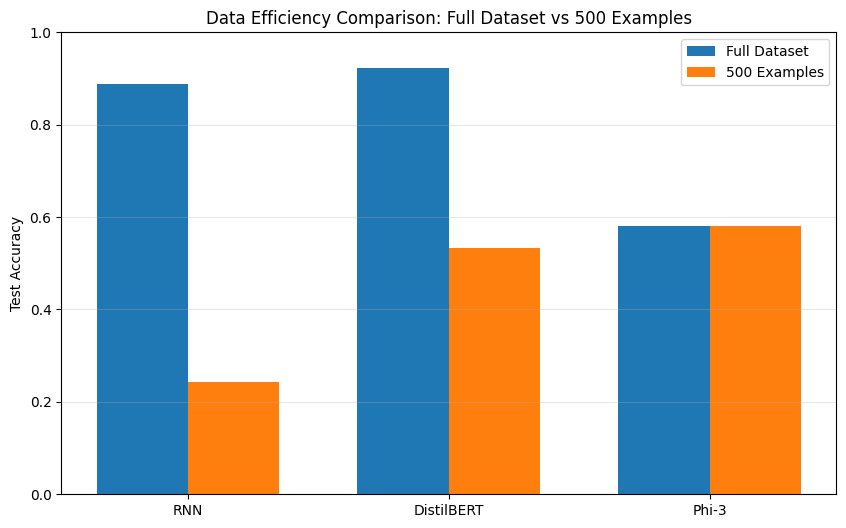

In [76]:
# Cell 79 — Data Efficiency Accuracy Plot

plot_df = data_efficiency_df[[
    "Model",
    "Full Dataset Accuracy",
    "500 Examples Accuracy"
]]

x = np.arange(len(plot_df["Model"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    plot_df["Full Dataset Accuracy"],
    width,
    label="Full Dataset"
)

plt.bar(
    x + width / 2,
    plot_df["500 Examples Accuracy"],
    width,
    label="500 Examples"
)

plt.xticks(x, plot_df["Model"])
plt.ylabel("Test Accuracy")
plt.title("Data Efficiency Comparison: Full Dataset vs 500 Examples")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# Cell 80 — Data Efficiency Discussion

The data-efficiency experiment shows that pretraining provides a major advantage when labeled data is limited.

The from-scratch RNN drops sharply when trained on only 500 examples because it must learn word meanings, sentence patterns, and the classification task only from the small dataset.

DistilBERT performs much better than the small-data RNN because it starts from pretrained language representations and only needs to adapt them to emotion classification.

Phi-3 does not require training, but its prompting performance is lower than fine-tuned DistilBERT because it is not directly optimized for the dataset labels.

In [77]:
# Cell 81 — Final Summary Table

final_summary_df = pd.DataFrame({
    "Model / Method": [
        "RNN Full Training",
        "DistilBERT Full Fine-Tuning",
        "Phi-3 Zero-Shot",
        "Phi-3 Few-Shot 3",
        "Phi-3 Few-Shot 8",
        "Phi-3 Chain-of-Thought",
        "RNN 500 Examples",
        "DistilBERT 500 Examples"
    ],
    "Accuracy": [
        rnn_test_accuracy,
        distilbert_test_accuracy,
        phi3_zero_shot_results["accuracy"],
        phi3_few_shot_3_results["accuracy"],
        phi3_few_shot_8_results["accuracy"],
        phi3_cot_results["accuracy"],
        small_rnn_test_accuracy,
        small_distilbert_test_accuracy
    ],
    "Macro F1": [
        rnn_test_macro_f1,
        distilbert_test_macro_f1,
        phi3_zero_shot_results["macro_f1"],
        phi3_few_shot_3_results["macro_f1"],
        phi3_few_shot_8_results["macro_f1"],
        phi3_cot_results["macro_f1"],
        small_rnn_test_macro_f1,
        small_distilbert_test_macro_f1
    ],
    "Training Time (s)": [
        rnn_training_time,
        distilbert_training_time,
        0,
        0,
        0,
        0,
        small_rnn_training_time,
        small_distilbert_training_time
    ],
    "Inference Time (s)": [
        rnn_inference_time,
        distilbert_inference_time,
        phi3_zero_shot_results["inference_time"],
        phi3_few_shot_3_results["inference_time"],
        phi3_few_shot_8_results["inference_time"],
        phi3_cot_results["inference_time"],
        small_rnn_inference_time,
        small_distilbert_inference_time
    ]
})

final_summary_df

,Model / Method,Accuracy,Macro F1,Training Time (s),Inference Time (s)
0,RNN Full Training,0.8875,0.838644,22.147372,0.115756
1,DistilBERT Full Fine-Tuning,0.9235,0.872884,588.206882,7.292063
2,Phi-3 Zero-Shot,0.5040,0.444738,0.000000,407.146846
3,Phi-3 Few-Shot 3,0.4975,0.464944,0.000000,540.753419
4,Phi-3 Few-Shot 8,0.5545,0.463071,0.000000,532.300261
5,Phi-3 Chain-of-Thought,0.5815,0.500932,0.000000,788.558655
6,RNN 500 Examples,0.2435,0.222655,2.965445,0.142395
7,DistilBERT 500 Examples,0.5335,0.509205,102.956384,7.300761


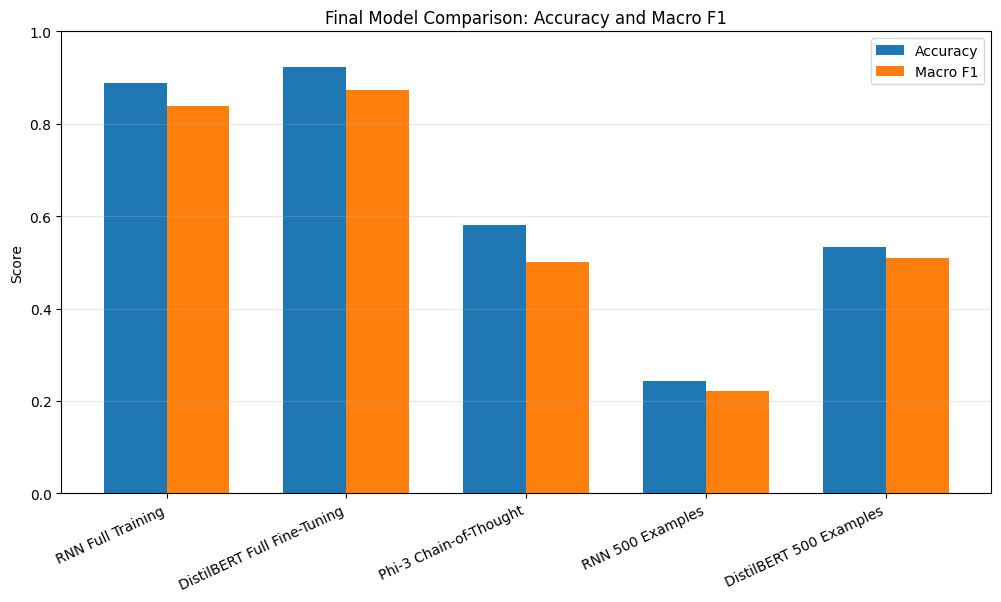

In [78]:
# Cell 82 — Final Accuracy and Macro F1 Plot

comparison_plot_df = final_summary_df[
    final_summary_df["Model / Method"].isin([
        "RNN Full Training",
        "DistilBERT Full Fine-Tuning",
        "Phi-3 Chain-of-Thought",
        "RNN 500 Examples",
        "DistilBERT 500 Examples"
    ])
]

x = np.arange(len(comparison_plot_df))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    comparison_plot_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    comparison_plot_df["Macro F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    comparison_plot_df["Model / Method"],
    rotation=25,
    ha="right"
)

plt.ylabel("Score")
plt.title("Final Model Comparison: Accuracy and Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Failure Modes Analysis

The confusion matrices show that the models most frequently confuse semantically related emotions.

The from-scratch RNN struggled the most with distinguishing between joy and love, as both classes contain positive emotional expressions with similar wording patterns. It also showed confusion between fear and surprise because short texts sometimes contain overlapping emotional cues.

DistilBERT reduced many of these errors due to pretrained contextual understanding, although some confusion between love and joy still remained. The transformer handled subtle contextual patterns better than the RNN baseline.

Phi-3 performed reasonably well in zero-shot and few-shot prompting settings, but its predictions were occasionally inconsistent on ambiguous samples. The model sometimes confused surprise with fear and sadness with anger when the emotional context was not explicit.

Overall, pretrained models demonstrated better semantic understanding and fewer confusion errors compared to the from-scratch RNN model.

# Cell 83 — Final Comparative Interpretation

The experiments show a clear difference between the three learning paradigms.

## From-Scratch RNN

The LSTM trained from scratch achieved strong performance when trained on the full dataset.  
However, when trained on only 500 examples, its performance dropped sharply.

This shows that from-scratch models require enough labeled data because they must learn:
- word representations
- sequence patterns
- classification boundaries

## Fine-Tuned DistilBERT

DistilBERT achieved the best overall performance.

It outperformed the RNN because it already had pretrained language knowledge before fine-tuning.

Its strong result on the 500-example subset shows that transfer learning is much more data-efficient than training from scratch.

## Phi-3 Prompting

Phi-3 required no training, which is a major advantage.

However, it performed worse than the supervised models because it was not fine-tuned specifically for this dataset.

Its inference time was also much higher because it generates text token-by-token.

Prompting is useful when:
- no training data is available
- fast experimentation is needed
- flexibility matters more than maximum accuracy

# Cell 84— Final Conclusion

This project compared three NLP learning paradigms on the same six-class emotion classification task.

The results show that:

1. **From-scratch RNNs can work well with enough data**, but they are weak in low-data settings.
2. **Fine-tuned transformers provide the best balance of accuracy and data efficiency**.
3. **LLM prompting is flexible and requires no training**, but it is slower and less accurate for this structured classification task.

Overall, the best-performing approach in this notebook is:

**Fine-tuned DistilBERT**

# Additional Note — Phi-3 Assignment Alignment

The LLM prompting section uses `microsoft/Phi-3-mini-4k-instruct`, as required by the assignment recommendation.

By default, the notebook evaluates Phi-3 on the full 2,000-example test split. A temporary fast subset option is included only for practice runs in Colab if runtime becomes too long.

For the final submitted notebook, keep `RUN_FULL_PHI3_TEST = True` so the Phi-3 results follow the assignment wording.


# Example Prompt Templates and Raw Outputs

## Zero-Shot Prompt Example

```text
Classify the emotion of the following text into one of these labels:
joy, sadness, anger, fear, love, surprise.

Text:
"I feel completely exhausted and hopeless."

Answer with only the emotion label.
```

### Example Raw Output
```text
sadness
```

---

## Few-Shot Prompt Example (3-Shot)

```text
Text: "I finally achieved my goal."
Label: joy

Text: "I am terrified about tomorrow."
Label: fear

Text: "I miss her so much."
Label: sadness

Now classify:
Text: "I cannot believe this amazing news!"
Label:
```

### Example Raw Output
```text
surprise
```

---

## Chain-of-Thought Prompt Example

```text
Read the text carefully and reason step-by-step about the emotion before giving the final label.

Text:
"Why does everything always go wrong for me?"

First explain your reasoning briefly, then output the final emotion label.
```

### Example Raw Output
```text
The text expresses frustration, hopelessness, and negative emotional reflection.
These cues are most associated with sadness.

Final Label: sadness
```


# Additional Discussion — Phi-3 Confusion Matrices

Confusion matrices are displayed for zero-shot, 3-shot, 8-shot, and chain-of-thought prompting.

This allows direct comparison of the failure modes of each prompting strategy, as requested in the assignment.
